In [27]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("loaded packages\n")

loaded packages



In [28]:
coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")
met_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/merged_met_plot_df.csv")

coral_df['scleractinia'] = np.where(coral_df['host_order'] == 'Scleractinia', 1, 0)
met_df['refined_origin'] = met_df['refined_origin'].str.replace('Host', 'Coral')
met_df = met_df[met_df['refined_origin'] == 'Coral']

print("loaded and cleaned data\n")

X = coral_df[coral_df.columns.intersection(met_df['metabolite'])]
y = coral_df['scleractinia']

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88, stratify=y)

/tmp/ipykernel_2806726/3402974339.py:1: DtypeWarning: Columns (8,17) have mixed types. Specify dtype option on import or set low_memory=False.
  coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")


loaded and cleaned data



### Feature Selection

In [29]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import f_classif

## variance threshold doesn't remove enough testing Kbest and percentile

In [30]:
# Initialize a dictionary to store the dataframes
importance_storage = {}

# Define your datasets and models
# We can get 100% accuracy using k=80
datasets = {
    "KBest": SelectKBest(f_classif, k=3623),
    # "Percentile_5": SelectPercentile(f_classif, percentile=5)
}

models = {
    "RandomForest": RandomForestClassifier(random_state=88, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=88, use_label_encoder=False, eval_metric='logloss')
}

# Original feature names from the intersection
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

for d_name, selector in datasets.items():
    selector.fit(X_train, y_train)
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)
    
    mask = selector.get_support()
    selected_features = feature_names[mask]
    
    for m_name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        print(f"\n{m_name} on {d_name}")
        print(confusion_matrix(y_test, y_pred))
        
        feat_imp_df = pd.DataFrame({
            'Metabolite': selected_features,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
        
        importance_storage[f"{m_name}_{d_name}"] = feat_imp_df

# importance_storage

/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 208  322  330  441  514  798 1015 1234 2124 2781 2900 3034 3156] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



RandomForest on KBest
[[28  0]
 [ 0 86]]


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:06:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost on KBest
[[28  0]
 [ 1 85]]


### Perm importance collinear features

In [31]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict

In [32]:
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

## Get top 500 metabolites instead from select K best
X_df = pd.DataFrame(
    X,
    columns=coral_df.columns.intersection(met_df['metabolite'])
)

# Split with DataFrames 
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=88, stratify=y
)

# Run SelectKBest on training data
k = min(500, X_train.shape[1])  
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

top_mets = X_train.columns[selector.get_support()].values


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 208  322  330  441  514  798 1015 1234 2124 2781 2900 3034 3156] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


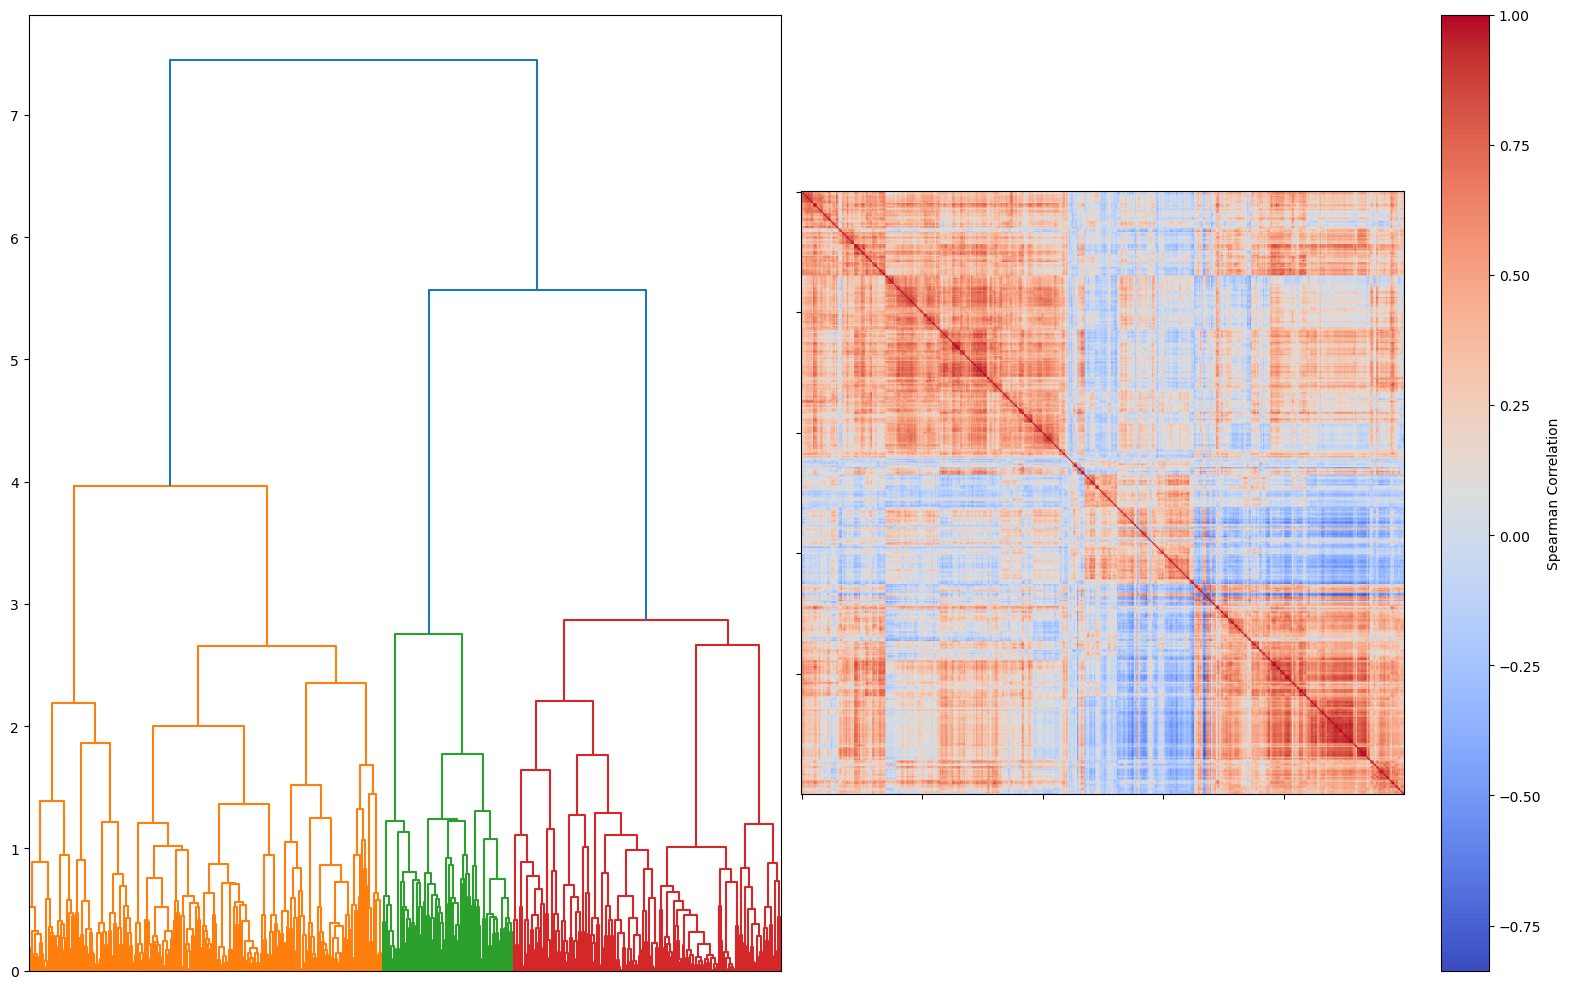

In [33]:
# top_mets = importance_storage["RandomForest_KBest"].head(500)['Metabolite'].values
# top_mets = importance_storage["XGBoost_KBest"].head(500)['Metabolite'].values
top_mets = X_train.columns[selector.get_support()].values

X_df = pd.DataFrame(X, columns=coral_df.columns.intersection(met_df['metabolite']))
X_subset = X_df[top_mets]

corr = spearmanr(X_subset).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

dendro = hierarchy.dendrogram(
    dist_linkage, labels=top_mets.tolist(), ax=ax1, leaf_rotation=90
)
ax1.set_xticklabels([])

im = ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]], cmap='coolwarm')
ax2.set_xticklabels([])
ax2.set_yticklabels([])


fig.colorbar(im, ax=ax2, label='Spearman Correlation')
fig.tight_layout()
plt.savefig('/work/hs325/World_Corals/misc/figs/perm_importance_heatmap_HostKBest.jpg')
plt.show()

In [34]:
from collections import defaultdict
from scipy.cluster import hierarchy
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cluster_ids = hierarchy.fcluster(dist_linkage, 1, criterion="distance")
n_features = len(cluster_ids)
print("Number of features in clustering:", n_features)

cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)

selected_features_indices = [v[0] for v in cluster_id_to_feature_ids.values()]

# defensive: make indices unique and sorted
selected_features_indices = sorted(set(selected_features_indices))
selected_features_names = feature_names[selected_features_indices]
print(f"Reduced feature set from {len(feature_names)} to {len(selected_features_names)} clusters.")

def select_columns(X, indices):
    if hasattr(X, "iloc"):   # pandas DataFrame
        return X.iloc[:, indices].values
    else:                    # numpy array
        return X[:, indices]

X_train_sel = select_columns(X_train, selected_features_indices)
X_test_sel  = select_columns(X_test,  selected_features_indices)

print("X_train_sel shape:", X_train_sel.shape)
print("X_test_sel  shape:", X_test_sel.shape)

clf_sel = RandomForestClassifier(random_state=88, n_jobs=-1)
clf_sel.fit(X_train_sel, y_train)

accuracy = clf_sel.score(X_test_sel, y_test)
print(f"Baseline accuracy on test data with redundant features removed: {accuracy:.2f}")

# print selected feature names
print("Selected feature names after clustering:")
for name in selected_features_names:
    print(name)


Number of features in clustering: 500
Reduced feature set from 3623 to 42 clusters.
X_train_sel shape: (454, 42)
X_test_sel  shape: (114, 42)
Baseline accuracy on test data with redundant features removed: 1.00
Selected feature names after clustering:
x22863_768_59077_10_971
x3156_482_36064_2_937
x19279_643_51751_9_054
x6124_510_39212_3_959
x23789_794_60652_11_52
x24987_796_62223_11_912
x26021_752_55957_12_218
x22281_518_49367_10_602
x23174_724_5283_11_167
x19255_518_49318_9_043
x22257_558_48585_10_595
x24838_770_60774_11_835
x3140_504_34195_2_931
x21481_743_57811_10_286
x19261_1286_02582_9_046
x26387_806_61119_12_325
x6689_344_35256_4_145
x31046_620_59826_13_466
x30258_690_60437_13_288
x23028_752_59618_11_083
x21104_667_51515_9_991
x24082_750_54463_11_628
x29160_618_58231_13_036
x34772_648_7388_14_298
x6270_488_31164_4_015
x17026_731_53528_8_146
x21089_682_59818_10_006
x4177_524_37207_3_374
x28474_866_66505_12_86
x5847_508_37732_3_864
x15427_747_52933_7_566
x46_234_12364_0_643
x20915_